Soil cracks are the result of changes in the volume of clay minerals as soil moisture changes, which cause the soil to shrink while drying and swell while wetting. Expansive soils usually have moderate to high clay content, particularly soils with a high content of montmorillonite, a typical clay of Vertisols. Soil cracks can lead to preferential water flow and rapid transport of solutes to deeper soil layers, and the expansion and contraction of the soil can damage roads and building foundations.

>Montmorillonite can expand up to fifteen times its dry volume and can exert an expansive pressure of 150,000 kg per square meter!

In this exercise we will identify soil cracks in a digital image using a filter designed to detect tubular structures, and then we will estimate the percentage of the area occupied by the cracks.

In [1]:
# Import modules
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color, filters, morphology


In [2]:
# Read image
RGB = io.imread('../datasets/images/soil_cracks.jpg')
print(RGB.shape) # Rows, columns, and color bands


(1224, 1632, 3)


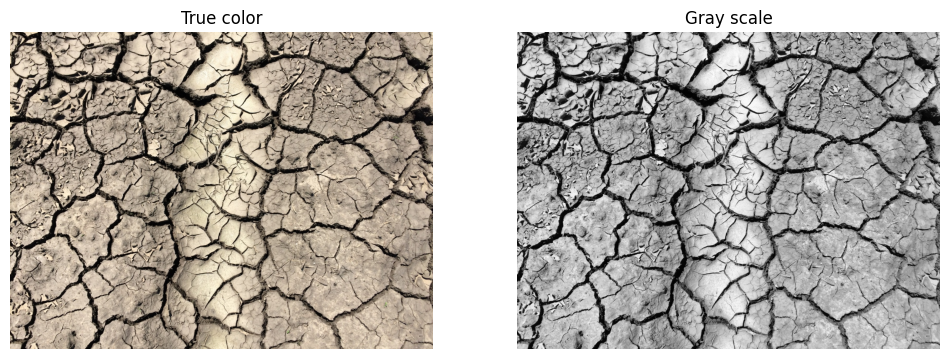

In [3]:
# Convert RGB image to gray scale
BW = color.rgb2gray(RGB)

# Compare true color and gray scale images
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.title('True color')
plt.imshow(RGB)
plt.axis('off')

plt.subplot(1,2,2)
plt.title('Gray scale')
plt.imshow(BW, cmap='gray')
plt.axis('off')
plt.show()


## Detect cracks

Soil cracks appear as dark, elongated features. Ridge filters, like the Sato and Frangi filters, highlight tubular structures (originally designed to detect blood vessels in medical images) and are well suited to detect cracks. The `sigmas` argument defines the range of widths (in pixels) of the structures that we want to detect, and `black_ridges=True` indicates that we are looking for dark features on a bright background.

In [4]:
# Sato tubeness filter
BW_sato = filters.sato(BW, sigmas=range(1,6), black_ridges=True)

# Frangi vesselness filter
BW_frangi = filters.frangi(BW, sigmas=range(1,6), black_ridges=True)


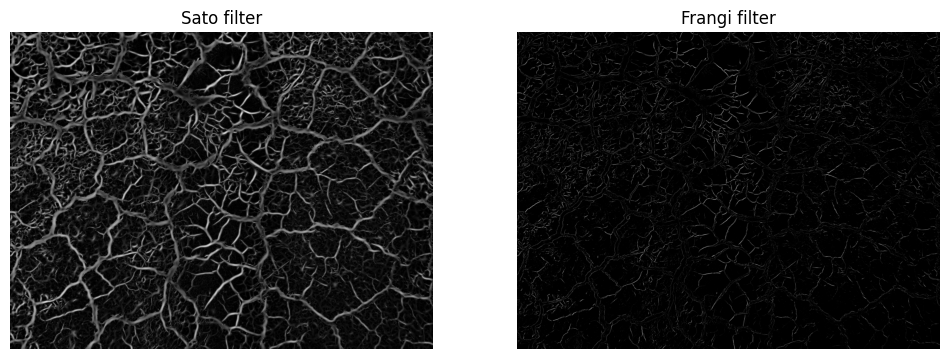

In [5]:
# Compare the Sato and Frangi filters
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.title('Sato filter')
plt.imshow(BW_sato, cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.title('Frangi filter')
plt.imshow(BW_frangi, cmap='gray')
plt.axis('off')

plt.show()


The Sato filter captures the soil cracks more clearly, although the results depend on the choice of filter parameters. Feel free to go back and run the filters with different `sigmas` values.

## Remove noise

The white top-hat transformation extracts small bright details that are smaller than a structuring element (in this case a disk with a radius of 2 pixels). By subtracting these small details from the filtered image we remove some of the noise.

In [6]:
# Generate structuring element
footprint = morphology.disk(2)
print(footprint)


[[0 0 1 0 0]
 [0 1 1 1 0]
 [1 1 1 1 1]
 [0 1 1 1 0]
 [0 0 1 0 0]]


In [7]:
# Extract small details (noise) using the white top-hat transformation
noise = morphology.white_tophat(BW_sato, footprint)

# Subtract noise from the filtered image
BW_sato_clean = BW_sato - noise


## Binarize image

To binarize the image we assign each pixel to either background or crack based on a threshold. Instead of selecting the threshold by trial and error, we will use Otsu's method, which finds the threshold that best separates the two groups of pixels in the histogram.

Threshold: 0.08


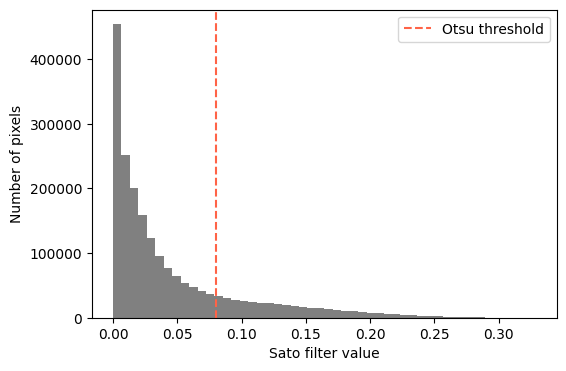

In [8]:
# Find threshold using Otsu's method
threshold = filters.threshold_otsu(BW_sato_clean)
print('Threshold:', round(threshold, 3))

# Histogram of filtered values
plt.figure(figsize=(6,4))
plt.hist(BW_sato_clean.flatten(), bins=50, color='gray')
plt.axvline(threshold, color='tomato', linestyle='--', label='Otsu threshold')
plt.xlabel('Sato filter value')
plt.ylabel('Number of pixels')
plt.legend()
plt.show()


In [9]:
# Classify pixels above the threshold as cracks
cracks = BW_sato_clean > threshold

# Remove isolated groups of pixels smaller than 200 pixels
cracks = morphology.remove_small_objects(cracks, min_size=200)


In [10]:
# Compute percentage of the area occupied by soil cracks
percentage_cracks = np.sum(cracks) / cracks.size * 100
print('Cracks occupy', round(percentage_cracks,1), '% of the area')


Cracks occupy 17.5 % of the area


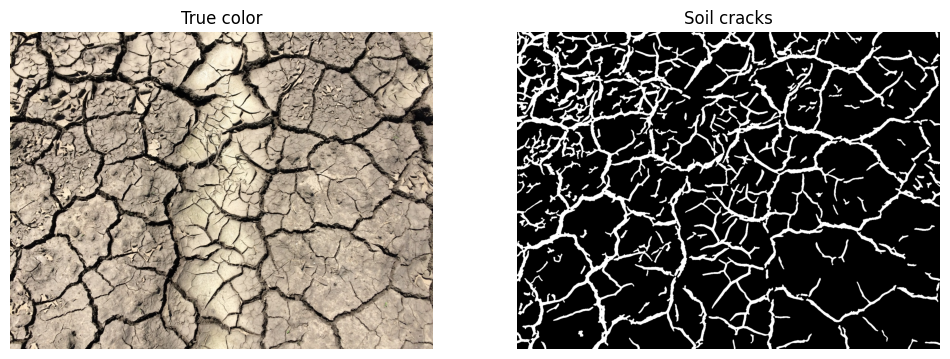

In [11]:
# Show final classification
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.title('True color')
plt.imshow(RGB)
plt.axis('off')

plt.subplot(1,2,2)
plt.title('Soil cracks')
plt.imshow(cracks, cmap='gray')
plt.axis('off')
plt.show()


## Practice

- Change the `sigmas` of the Sato filter to `range(1,3)` and `range(3,10)`. How does the width of the detected cracks change?

- Repeat the classification without removing small objects. How much does the percentage of the area occupied by cracks change?

- Use the `morphology.skeletonize()` function to reduce the cracks to lines with a width of one pixel and estimate the total length of cracks in pixels.